In [10]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

from xgboost import XGBClassifier

RANDOM_STATE = 42


## Dataset Loading

The dataset should be downloaded from Kaggle and placed in the project folder.

Expected file name: `Country-data.csv`

In [11]:
import os

if not os.path.exists("Country-data.csv"):
    !pip -q install kaggle
    !kaggle datasets download -d rohan0301/unsupervised-learning-on-country-data
    !unzip -o unsupervised-learning-on-country-data.zip

import pandas as pd
df = pd.read_csv("Country-data.csv")

In [12]:
assert df.shape[0] > 0, "Dataset is empty"
assert df.shape[1] > 0, "No columns found"
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [14]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [15]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [16]:
df.columns = df.columns.str.strip()
df = df.drop_duplicates()

for col in df.columns:
    if col != "country":
        df[col] = pd.to_numeric(df[col], errors="coerce")

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Exploratory Data Analysis

EDA helps to understand the dataset before building models.

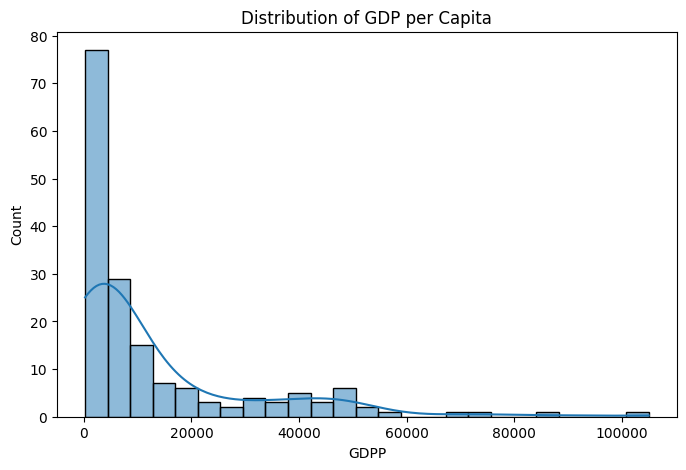

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(df["gdpp"], bins=25, kde=True)
plt.title("Distribution of GDP per Capita")
plt.xlabel("GDPP")
plt.ylabel("Count")
plt.show()

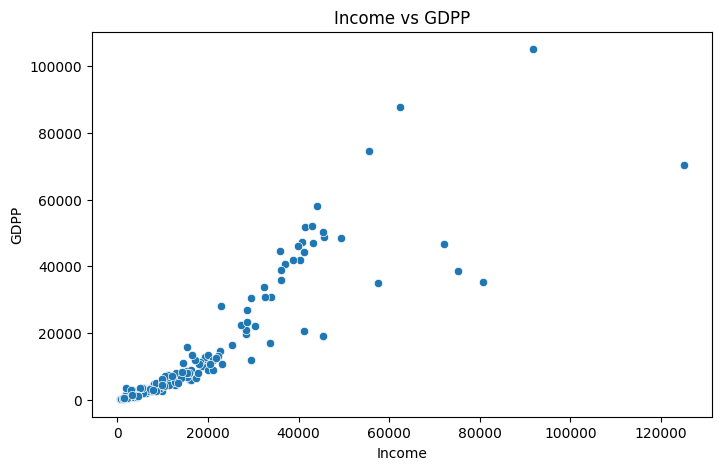

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="income", y="gdpp")
plt.title("Income vs GDPP")
plt.xlabel("Income")
plt.ylabel("GDPP")
plt.show()

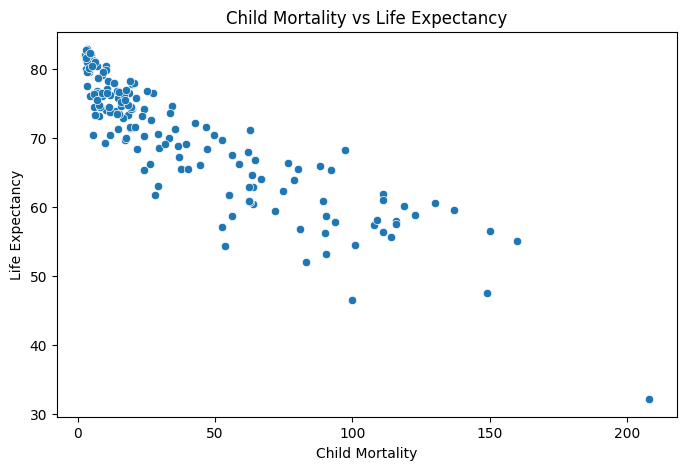

In [19]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="child_mort", y="life_expec")
plt.title("Child Mortality vs Life Expectancy")
plt.xlabel("Child Mortality")
plt.ylabel("Life Expectancy")
plt.show()

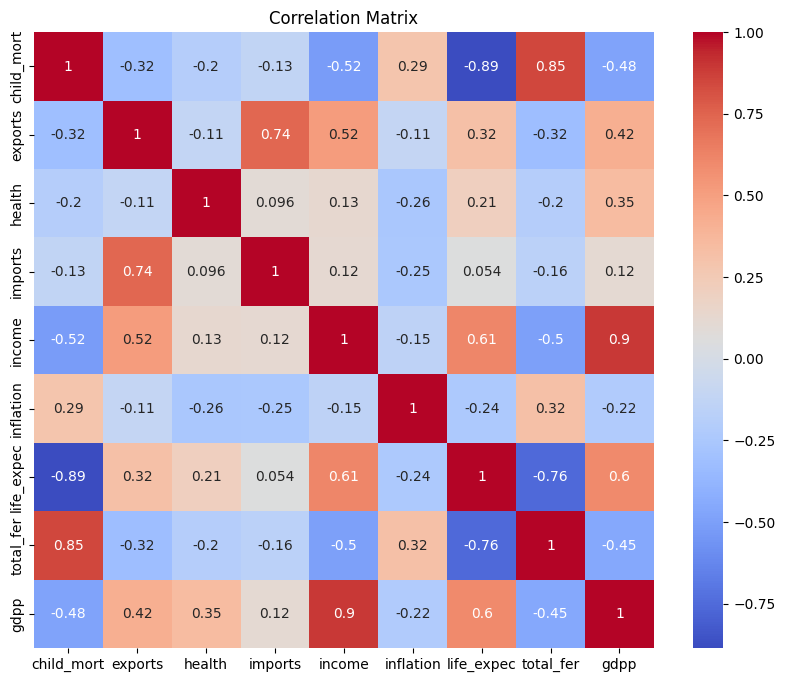

In [20]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## EDA Findings

Countries with higher income and GDPP generally look more developed.

Countries with high child mortality usually have lower life expectancy.

These patterns can help in classification and segmentation.

## Creating a Classification Target

The dataset is mainly for unsupervised learning, so I created a simple target column.

`High_Need` = 1 if a country has high child mortality, low income and low GDPP.

This target is used only for learning classification models.

In [21]:
child_limit = df["child_mort"].median()
income_limit = df["income"].median()
gdpp_limit = df["gdpp"].median()

df["High_Need"] = (
    (df["child_mort"] > child_limit) &
    (df["income"] < income_limit) &
    (df["gdpp"] < gdpp_limit)
).astype(int)

df["High_Need"].value_counts()

,count
High_Need,
0,100
1,67


In [22]:
features = [
    "child_mort", "exports", "health", "imports", "income",
    "inflation", "life_expec", "total_fer", "gdpp"
]

X = df[features]
y = df["High_Need"]

## Train-Test Split

I used train-test split for classification.

In [23]:
stratify_value = y if y.value_counts().min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=stratify_value
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (125, 9)
Test shape: (42, 9)


## Classification Models

I trained two ensemble classification models:

- Random Forest
- XGBoost


In [24]:
def get_scores(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0)
    }

In [25]:
# Direct Random Forest and XGBoost classifiers
rf_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1))
])

xgb_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_jobs=1
    ))
])

models = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}


In [26]:
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    row = {"Model": name}
    row.update(get_scores(y_test, pred))
    results.append(row)

    trained_models[name] = model

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.97619,0.944444,1.0,0.971429
1,XGBoost,0.97619,0.944444,1.0,0.971429


In [27]:
best_model_name = results_df.sort_values("F1 Score", ascending=False).iloc[0]["Model"]
best_model = trained_models[best_model_name]

best_pred = best_model.predict(X_test)

print("Best Model:", best_model_name)
print(classification_report(y_test, best_pred, zero_division=0))

Best Model: Random Forest
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        25
           1       0.94      1.00      0.97        17

    accuracy                           0.98        42
   macro avg       0.97      0.98      0.98        42
weighted avg       0.98      0.98      0.98        42



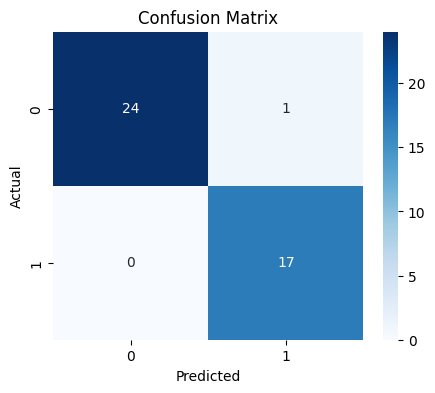

In [28]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Hyperparameter Tuning

I used GridSearchCV to improve the Random Forest model.

In [29]:
rf_grid = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1))
    ]),
    {
        "model__n_estimators": [50, 100],
        "model__max_depth": [3, 5, None]
    },
    cv=3,
    scoring="f1"
)

rf_grid.fit(X_train, y_train)

print("Best RF Params:", rf_grid.best_params_)
print("Best CV F1:", rf_grid.best_score_)

Best RF Params: {'model__max_depth': 3, 'model__n_estimators': 50}
Best CV F1: 0.9696224922031375


In [30]:
tuned_rf = rf_grid.best_estimator_
tuned_pred = tuned_rf.predict(X_test)

tuned_scores = get_scores(y_test, tuned_pred)
tuned_scores

{'Accuracy': 0.9523809523809523,
 'Precision': 0.8947368421052632,
 'Recall': 1.0,
 'F1 Score': 0.9444444444444444}

## K-Means Clustering

K-Means is used to segment countries/customers into groups.

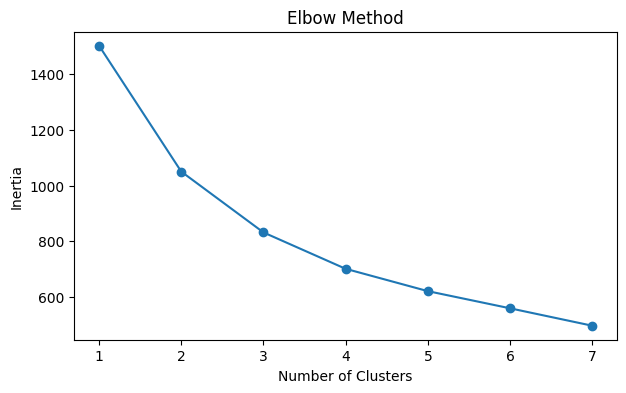

In [31]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

inertia = []
cluster_range = range(1, 8)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(cluster_range, inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [32]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"].value_counts()

,count
KMeans_Cluster,
2,84
1,47
0,36


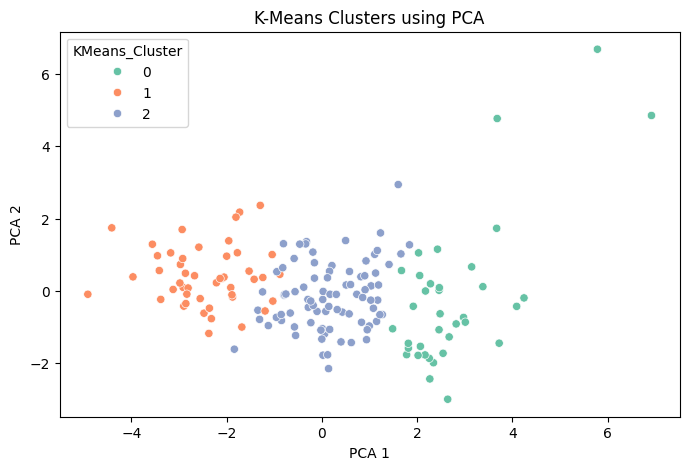

In [33]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_data = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=df["KMeans_Cluster"], palette="Set2")
plt.title("K-Means Clusters using PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [34]:
cluster_profile = df.groupby("KMeans_Cluster")[features].mean()
cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


## DBSCAN Clustering

DBSCAN is another clustering method. It can also mark some points as noise using cluster label `-1`.

In [35]:
dbscan = DBSCAN(eps=2.0, min_samples=4)
df["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"].value_counts()

,count
DBSCAN_Cluster,
0,155
-1,12


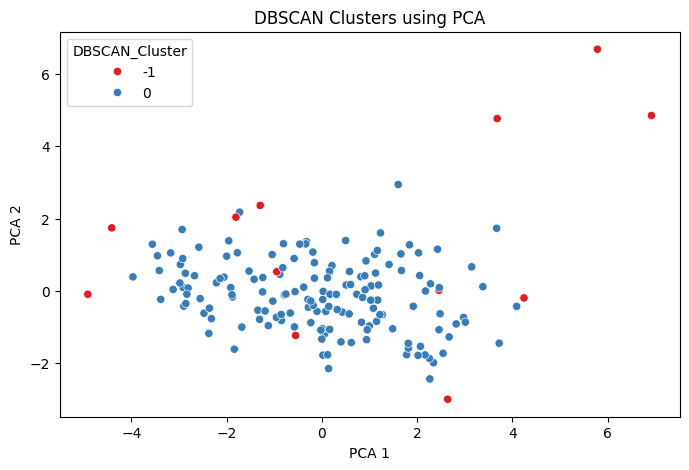

In [36]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=df["DBSCAN_Cluster"], palette="Set1")
plt.title("DBSCAN Clusters using PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

## Customer Segmentation Insights

Here I give simple names to K-Means clusters using average GDPP.

In [37]:
gdpp_order = cluster_profile["gdpp"].sort_values().index.tolist()

segment_names = {
    gdpp_order[0]: "High Need Segment",
    gdpp_order[1]: "Developing Segment",
    gdpp_order[2]: "Developed Segment"
}

df["Segment"] = df["KMeans_Cluster"].map(segment_names)

df[["country", "KMeans_Cluster", "Segment", "High_Need"]].head(10)

,country,KMeans_Cluster,Segment,High_Need
0,Afghanistan,1,High Need Segment,1
1,Albania,2,Developing Segment,0
2,Algeria,2,Developing Segment,0
3,Angola,1,High Need Segment,1
4,Antigua and Barbuda,2,Developing Segment,0
5,Argentina,2,Developing Segment,0
6,Armenia,2,Developing Segment,0
7,Australia,0,Developed Segment,0
8,Austria,0,Developed Segment,0
9,Azerbaijan,2,Developing Segment,0


In [38]:
segment_summary = df.groupby("Segment")[features + ["High_Need"]].mean()
segment_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,High_Need
Segment,,,,,,,,,,
Developed Segment,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,0.000000
Developing Segment,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381,0.309524
High Need Segment,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979,0.872340


## Final Insights

- Random Forest and XGBoost/Boosting were used for classification.
- K-Means created clear customer/country segments.
- DBSCAN helped identify dense groups and possible noise points.
- High Need Segment has lower GDPP/income and higher child mortality.
- Developed Segment has higher income, higher GDPP and better life expectancy.

This system can help identify which customer/country groups need more attention.

# Conclusion

An end-to-end Customer Intelligence System was built.

The project covered:
- Data cleaning
- EDA
- Classification
- Ensemble learning
- Random Forest
- XGBoost
- Hyperparameter tuning
- K-Means clustering
- DBSCAN clustering
- Actionable segmentation insights